### Loading & Testing NLP Model

In [82]:
import requests
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
import json
import pandas as pd

In [83]:
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading spaCy model 'en_core_web_md'...")
    nlp = spacy.load("en_core_web_md")

In [84]:
nlp.add_pipe("spacytextblob")

doc = nlp("Argentina faces severe economic crisis")
print(doc._.blob.polarity)  # returns -1 to +1

0.2


### Testing Natural Language Processing (NLP)

In [85]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyser = SentimentIntensityAnalyzer()

def sentiment_score(text):

    scores = analyser.polarity_scores(text)
    compound = scores["compound"]

    if compound <= -0.6:
        label = "Very negative"
        score = 1
    elif compound <= -0.2:
        label = "Negative"
        score = 2
    elif compound < 0.2:
        label = "Neutral"
        score = 3
    elif compound < 0.6:
        label = "Positive"
        score = 4
    else:
        label = "Very positive"
        score = 5

    return {
        "label": label,
        "score": score,
        "compound": round(compound, 3),
        "details": scores
    }

example_headlines = ["UK borrowing costs hit highest since 2008 financial crisis. The interest rate on government debt is climbing over fears about inflation, interest rates",
                     "Stock markets surge and oil tumbles as Trump postpones power plant strikes after 'very good and productive' talks with Iran"]

for headline in example_headlines:
  print(headline)
  print(sentiment_score(headline))
  print("\n")

UK borrowing costs hit highest since 2008 financial crisis. The interest rate on government debt is climbing over fears about inflation, interest rates
{'label': 'Negative', 'score': 2, 'compound': -0.527, 'details': {'neg': 0.281, 'neu': 0.539, 'pos': 0.18, 'compound': -0.5267}}


Stock markets surge and oil tumbles as Trump postpones power plant strikes after 'very good and productive' talks with Iran
{'label': 'Neutral', 'score': 3, 'compound': -0.104, 'details': {'neg': 0.186, 'neu': 0.686, 'pos': 0.129, 'compound': -0.1045}}




### Creating & Populating the Database

In [86]:
import sqlite3
from pathlib import Path

DB_PATH = Path("../data/articles.db")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

def create_database(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS articles (
        article_id TEXT PRIMARY KEY,
        country TEXT,
        date TEXT,
        source_name TEXT,
        title TEXT,
        description TEXT,
        url TEXT,
        published_at TEXT
    )
    """)

    conn.commit()
    return conn, cursor

conn, cursor = create_database(DB_PATH)

In [87]:
# INSERT FUNCTION

def insert_articles(cursor, conn, articles):

    inserted = 0

    for a in articles:

        cursor.execute("""
            INSERT OR IGNORE INTO articles (
                article_id,
                country,
                date,
                source_name,
                title,
                description,
                url,
                published_at
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            a["article_id"],
            a["country"],
            a["date"],
            a["source_name"],
            a["title"],
            a["description"],
            a["url"],
            a["published_at"]
        ))

        inserted += cursor.rowcount

    conn.commit()

    print(f"  Inserted into DB: {inserted}")

In [88]:
import requests

def fetch_guardian(country, begin_date, end_date, api_key):

    print("\nGUARDIAN FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print("Missing Guardian API key")
        return []

    url = "https://content.guardianapis.com/search"

    # ----------------------------
    # EXPANDED ECONOMIC QUERY SET
    # ----------------------------
    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth",
        f"{country} central bank",
        f"{country} fiscal policy"
    ]

    all_articles = []

    for q in queries:

        params = {
            "q": q,
            "from-date": begin_date,
            "to-date": end_date,
            "page-size": 200,
            "order-by": "newest",
            "show-fields": "headline,trailText",
            "api-key": api_key
        }

        print(f"  Query: {q}")

        response = requests.get(url, params=params)

        print(f"  Status code: {response.status_code}")

        if response.status_code != 200:
            print(" request failed")
            print(response.text)
            continue

        try:
            data = response.json()
        except Exception as e:
            print(f" JSON decode error: {e}")
            continue

        results = data.get("response", {}).get("results", [])

        print(f"  Articles returned: {len(results)}")

        for article in results:

            fields = article.get("fields", {})
            published_at = article.get("webPublicationDate")

            all_articles.append({
                "article_id": article.get("id"),
                "country": country,
                "date": published_at[:10] if published_at else None,
                "source_name": "The Guardian",
                "title": fields.get("headline"),
                "description": fields.get("trailText"),
                "url": article.get("webUrl"),
                "published_at": published_at
            })

    return all_articles

In [89]:
import requests

NEWSAPI_ENDPOINT = "https://newsapi.org/v2/everything"

def fetch_newsapi(country, date_str, api_key):

    print("\n NEWSAPI FETCH START")
    print(f"   Country: {country}")
    print(f"   Date: {date_str}")

    if not api_key:
        print(" Missing NewsAPI key")
        return []

    # ----------------------------
    # EXPANDED ECONOMIC QUERIES
    # ----------------------------
    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth",
        f"{country} central bank",
        f"{country} fiscal policy"
    ]

    all_articles = []

    for query in queries:

        params = {
            "q": query,
            "from": date_str,
            "to": date_str,
            "language": "en",
            "sortBy": "publishedAt",   # more stable than relevancy
            "pageSize": 50,
            "apiKey": api_key
        }

        print(f"  Query: {query}")

        response = requests.get(NEWSAPI_ENDPOINT, params=params)

        if response.status_code != 200:
            print(f"  Error: {response.text}")
            continue

        data = response.json()
        articles = data.get("articles", [])

        print(f"  Returned: {len(articles)}")

        for i, a in enumerate(articles):

            all_articles.append({
                "article_id": f"newsapi_{country}_{date_str}_{query}_{i}",
                "country": country,
                "date": date_str,
                "source_name": a.get("source", {}).get("name"),
                "title": a.get("title"),
                "description": a.get("description"),
                "url": a.get("url"),
                "published_at": a.get("publishedAt")
            })

    return all_articles

In [90]:
# NYT FETCH FUNCTION (MONTH RANGE)
import requests

def fetch_nyt(country, begin_date, end_date, api_key):

    print("\n NYT FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print(" Missing NYT API key")
        return []

    url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

    params = {
        "q": f"{country} (economy OR GDP OR inflation OR growth OR macro OR fiscal OR monetary)",
        "begin_date": begin_date,
        "end_date": end_date,
        "sort": "newest",
        "api-key": api_key
    }

    print(f"  Requesting NYT API...")

    response = requests.get(url, params=params)

    print(f" Status code: {response.status_code}")

    # ---- Rate limit handling ----
    if response.status_code == 429:
        print("  RATE LIMITED — skipping request")
        return []

    # ---- Bad response handling ----
    if response.status_code != 200:
        print("   Request failed")
        print(response.text)
        return []

    try:
        data = response.json()
    except Exception as e:
        print(f"  JSON decode error: {e}")
        return []

    docs = data.get("response", {}).get("docs", [])

    if docs is None:
        docs = []

    print(f"  Articles returned: {len(docs)}")

    articles = []

    for doc in docs:

        published_at = doc.get("pub_date")

        article = {
            "article_id": doc.get("_id"),

            "country": country,

            # extract YYYY-MM-DD
            "date": published_at[:10] if published_at else None,

            "source_name": "New York Times",

            "title": doc.get("headline", {}).get("main"),

            "description": doc.get("abstract"),

            "url": doc.get("web_url"),

            "published_at": published_at
        }

        articles.append(article)

    print(f"   Parsed articles: {len(articles)}")

    return articles

In [91]:
#cannot operate on a closed database
import sqlite3
from pathlib import Path

DB_PATH = Path("../data/articles.db")

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

In [92]:
import requests
import time

def safe_request(url, params, retries=3):

    for i in range(retries):
        try:
            response = requests.get(url, params=params, timeout=15)

            # If rate limited, wait and retry
            if response.status_code == 429:
                print("Rate limited (429). Sleeping...")
                time.sleep(5)
                continue

            return response

        except requests.exceptions.SSLError:
            print(f"SSL error (attempt {i+1}) — retrying...")
            time.sleep(2)

        except requests.exceptions.RequestException as e:
            print(f"Request error (attempt {i+1}): {e}")
            time.sleep(2)

    return None


def fetch_nyt(country, begin_date, end_date, api_key):

    print("\nNYT FETCH START")
    print(f"Country: {country}")

    if not api_key:
        print("Missing NYT API key")
        return []

    url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

    # ----------------------------
    # SPLIT QUERIES (NO OR BLOCKS)
    # ----------------------------
    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth"
    ]

    all_articles = []

    for q in queries:

        params = {
            "q": q,
            "begin_date": begin_date,
            "end_date": end_date,
            "sort": "newest",
            "api-key": api_key
        }

        print(f" Query: {q}")

        response = safe_request(url, params)

        if response is None:
            print("Request failed after retries")
            continue

        if response.status_code != 200:
            print(f"Error {response.status_code}: {response.text}")
            continue

        data = response.json()
        docs = data.get("response", {}).get("docs", [])

        print(f" Articles returned: {len(docs)}")

        for doc in docs:

            published_at = doc.get("pub_date")

            all_articles.append({
                "article_id": doc.get("_id"),
                "country": country,
                "date": published_at[:10] if published_at else None,
                "source_name": "New York Times",
                "title": doc.get("headline", {}).get("main"),
                "description": doc.get("abstract"),
                "url": doc.get("web_url"),
                "published_at": published_at
            })

        # ----------------------------
        # IMPORTANT: RATE LIMIT CONTROL
        # ----------------------------
        time.sleep(1)

    return all_articles

### Querying the SQLite Database

In [93]:
conn = sqlite3.connect("../data/articles.db")

query = "SELECT DISTINCT country FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

     country
0  Argentina
1      India
2  Indonesia
3    Nigeria
4     Turkey
5    Vietnam


In [94]:
conn = sqlite3.connect("../data/articles.db")

query = "SELECT * FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

                                            article_id  country        date  \
0    business/live/2026/jan/02/uk-house-prices-drop...    India  2026-01-02   
1    business/2026/jan/06/jaguar-land-rover-sales-u...    India  2026-01-06   
2    business/live/2026/jan/06/jlr-sales-hit-by-cyb...    India  2026-01-06   
3    business/2026/jan/06/bank-of-england-venezuela...  Vietnam  2026-01-06   
4    business/2026/jan/08/shadow-fleet-ships-sancti...   Turkey  2026-01-08   
..                                                 ...      ...         ...   
574                   b91d3ab7ecea495c8dd65a57d39478db   Turkey  2026-04-22   
575                   ba0d9b11ffce9d8c9bf44b88eb4d0005   Turkey  2026-04-22   
576                   91a0820849226ce7191a4dcfe6894603   Turkey  2026-04-22   
577                   1b82a58fba64c0b5328abf4c7e21e21c   Turkey  2026-04-22   
578                   2949e8137d60035ef4e7ecbab5ce8f2d   Turkey  2026-04-22   

      source_name                                  

In [95]:

conn = sqlite3.connect("../data/articles.db")

table_name = "articles"

query = f"""
PRAGMA table_info({table_name});
"""

df_columns = pd.read_sql_query(query, conn)

print(df_columns)

conn.close()

    cid                     name  type  notnull dflt_value  pk
0     0               article_id  TEXT        0       None   1
1     1                  country  TEXT        0       None   0
2     2                     date  TEXT        0       None   0
3     3              source_name  TEXT        0       None   0
4     4                    title  TEXT        0       None   0
5     5              description  TEXT        0       None   0
6     6                      url  TEXT        0       None   0
7     7             published_at  TEXT        0       None   0
8     8          sentiment_score  REAL        0       None   0
9     9    sentiment_score_vader  REAL        0       None   0
10   10  sentiment_score_finbert  REAL        0       None   0


In [96]:
import sqlite3
import pandas as pd
from textblob import TextBlob

# CONNECT DB
conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()

# ADD COLUMN
try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_score_vader REAL
    """)
    conn.commit()
    print("VADER column created.")
except sqlite3.OperationalError:
    print("VADER column already exists.")

# LOAD DATA
df_articles = pd.read_sql_query("""
SELECT article_id, title
FROM articles
""", conn)

# SENTIMENT FUNCTION
def sentiment_vader(text):
    if pd.isna(text):
        return None
    return TextBlob(text).sentiment.polarity

# UPDATE LOOP
for _, row in df_articles.iterrows():
    article_id = row["article_id"]
    title = row["title"]

    score = sentiment_vader(title)

    cursor.execute("""
    UPDATE articles
    SET sentiment_score_vader = ?
    WHERE article_id = ?
    """, (score, article_id))

conn.commit()

# CHECK OUTPUT
df_vader = pd.read_sql_query("""
SELECT title, sentiment_score_vader, date, country
FROM articles
""", conn)

print(df_vader.head())

conn.close()

VADER column already exists.
                                               title  sentiment_score_vader  \
0  FTSE 100 hits 10,000 point milestone for first...                  0.625   
1  Jaguar Land Rover sales slump sharply amid US ...                 -0.125   
2  FTSE 100 posts best day in six months as stock...                  1.000   
3  Deep in the vaults: the Bank of England’s £1.4...                  0.000   
4  ‘Shadow fleet’ ships moving sanctioned oil ref...                  0.000   

         date  country  
0  2026-01-02    India  
1  2026-01-06    India  
2  2026-01-06    India  
3  2026-01-06  Vietnam  
4  2026-01-08   Turkey  


In [97]:
import sqlite3
import pandas as pd
from transformers import pipeline

finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")


conn = sqlite3.connect("../data/articles.db", timeout=30)

df_articles = pd.read_sql_query("""
SELECT article_id, title
FROM articles
WHERE title IS NOT NULL
""", conn)

conn.close() 

# SENTIMENT FUNCTION
def finbert_signed(text):
    result = finbert(text)[0]
    label = result["label"]
    score = result["score"]

    return score if label == "positive" else -score if label == "negative" else 0.0

df_articles["sentiment_score_finbert"] = df_articles["title"].apply(finbert_signed)

# REOPEN CONNECTION ONLY FOR WRITE
conn = sqlite3.connect("../data/articles.db", timeout=30)
cursor = conn.cursor()

# ensure column exists
try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_score_finbert REAL
    """)
    conn.commit()
except sqlite3.OperationalError:
    pass

# BULK UPDATE
cursor.executemany("""
UPDATE articles
SET sentiment_score_finbert = ?
WHERE article_id = ?
""", list(zip(
    df_articles["sentiment_score_finbert"],
    df_articles["article_id"]
)))

conn.commit()
conn.close()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25695.07it/s]


In [98]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/articles.db")

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()

df_finbert["date"] = pd.to_datetime(df_finbert["date"])

df_finbert.head()

,date,country,sentiment_score_finbert
0,2026-01-02,India,0.879452
1,2026-01-06,India,-0.973458
2,2026-01-06,India,0.723519
3,2026-01-06,Vietnam,0.000000
4,2026-01-08,Turkey,0.000000


In [99]:
countries = ["Turkey", "India", "Indonesia", "Argentina"]

df_plot = df_finbert[df_finbert["country"].isin(countries)]

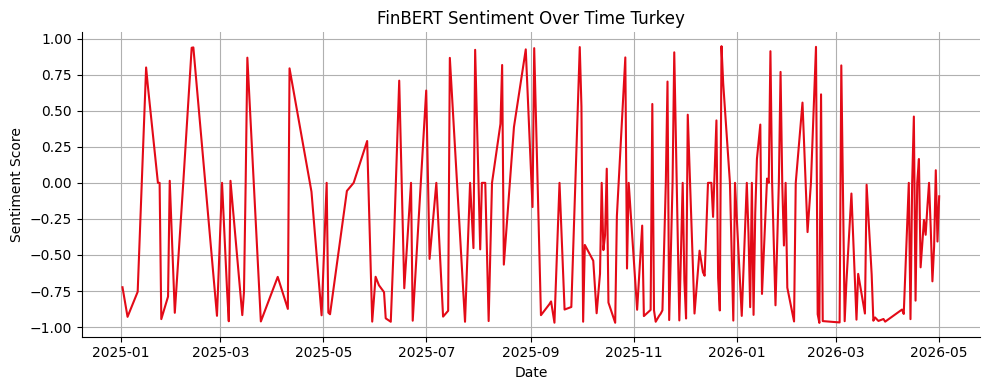

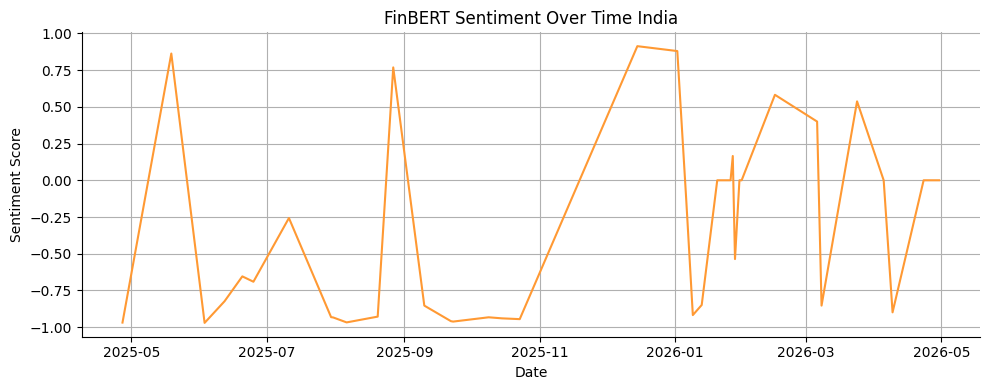

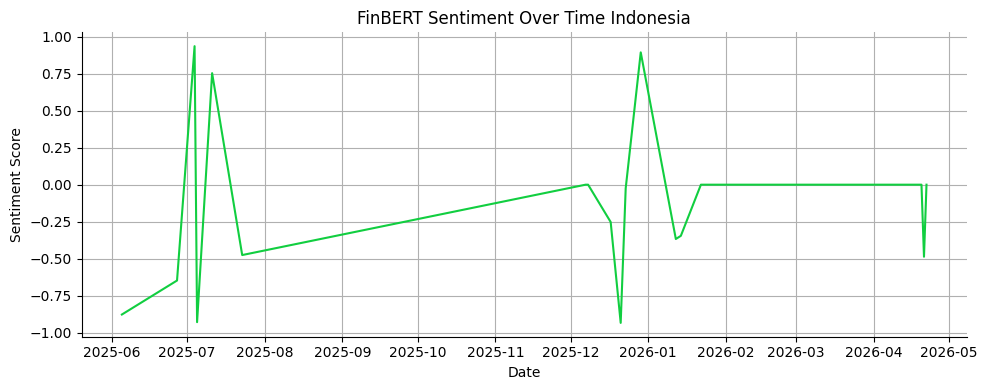

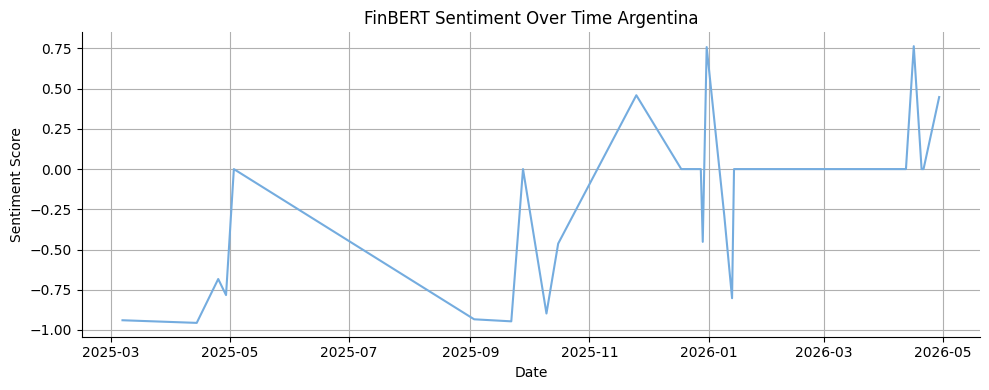

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# LOAD DATA
conn = sqlite3.connect("../data/articles.db")

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()

# CLEAN DATA
df_finbert["date"] = pd.to_datetime(df_finbert["date"])

# COLOUR MAP
colors = {
    "Turkey": "#E30A17",    
    "Indonesia": "#11CE40", 
    "India": "#FF9933",      
    "Argentina": "#74ACDF"   
}

countries = ["Turkey", "India", "Indonesia", "Argentina"]

# PLOTTING (ONE FIGURE EACH)
for country in countries:

    subset = df_finbert[df_finbert["country"] == country]

    daily = subset.groupby("date")["sentiment_score_finbert"].mean()

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        daily.index,
        daily.values,
        color=colors[country]
    )

    ax.set_title(f"FinBERT Sentiment Over Time {country}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sentiment Score")

    ax.grid(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# LOAD DATA
conn = sqlite3.connect("../data/articles.db")

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()

# CLEAN DATA
df_finbert["date"] = pd.to_datetime(df_finbert["date"])

# COLOUR MAP
colors = {
    "Turkey": "#E30A17",
    "Indonesia": "#11CE40",
    "India": "#FF9933",
    "Argentina": "#74ACDF"
}

countries = ["Turkey", "India", "Indonesia", "Argentina"]

# PLOTTING
for country in countries:

    subset = df_finbert[df_finbert["country"] == country]

    # daily average sentiment
    daily = subset.groupby("date")["sentiment_score_finbert"].mean()

    # cumulative sentiment (KEY CHANGE)
    cumulative = daily.cumsum()

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        cumulative.index,
        cumulative.values,
        color=colors[country]
    )

    ax.set_title(f"Cumulative FinBERT Sentiment — {country}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Sentiment")

    ax.grid(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

In [101]:
df_vader

,title,sentiment_score_vader,date,country
0,"FTSE 100 hits 10,000 point milestone for first...",0.625000,2026-01-02,India
1,Jaguar Land Rover sales slump sharply amid US ...,-0.125000,2026-01-06,India
2,FTSE 100 posts best day in six months as stock...,1.000000,2026-01-06,India
3,Deep in the vaults: the Bank of England’s £1.4...,0.000000,2026-01-06,Vietnam
4,‘Shadow fleet’ ships moving sanctioned oil ref...,0.000000,2026-01-08,Turkey
...,...,...,...,...
574,Temporary protected status holders add $29bn t...,0.000000,2026-04-22,Turkey
575,Strait of Hormuz is hosting gunboat diplomacy ...,0.550000,2026-04-22,Turkey
576,Zelenskyy says EU unblocking of €90bn loan for...,0.285714,2026-04-22,Turkey
577,Trump approval slips as polls show warning sig...,0.000000,2026-04-22,Turkey


In [102]:
df_plot.dtypes

date                       datetime64[us]
country                               str
sentiment_score_finbert           float64
dtype: object

In [103]:
df_plot["date"] = pd.to_datetime(df_plot["date"])

In [104]:
df_plot.dtypes

date                       datetime64[us]
country                               str
sentiment_score_finbert           float64
dtype: object

In [105]:
turkey = pd.read_csv("../data/turkey.csv")
turkey

,observation_date,CCUSMA02TRM618N
0,1957-01-01,0.000003
1,1957-02-01,0.000003
2,1957-03-01,0.000003
3,1957-04-01,0.000003
4,1957-05-01,0.000003
...,...,...
826,2025-11-01,42.240315
827,2025-12-01,42.645826
828,2026-01-01,43.161714
829,2026-02-01,43.647910


In [106]:
df_india = pd.read_csv("../data/india.csv")
df_india

,observation_date,DEXINUS
0,2021-04-26,74.75
1,2021-04-27,74.58
2,2021-04-28,74.49
3,2021-04-29,74.07
4,2021-04-30,74.00
...,...,...
1300,2026-04-20,93.13
1301,2026-04-21,93.50
1302,2026-04-22,93.79
1303,2026-04-23,94.11


In [107]:
df_indonesia = pd.read_csv("../data/indonesia.csv")
df_indonesia

,observation_date,CCUSMA02IDM618N
0,1967-01-01,137.000000
1,1967-02-01,137.000000
2,1967-03-01,137.000000
3,1967-04-01,137.000000
4,1967-05-01,137.000000
...,...,...
706,2025-11-01,16703.050000
707,2025-12-01,16707.130435
708,2026-01-01,16827.954545
709,2026-02-01,16825.700000


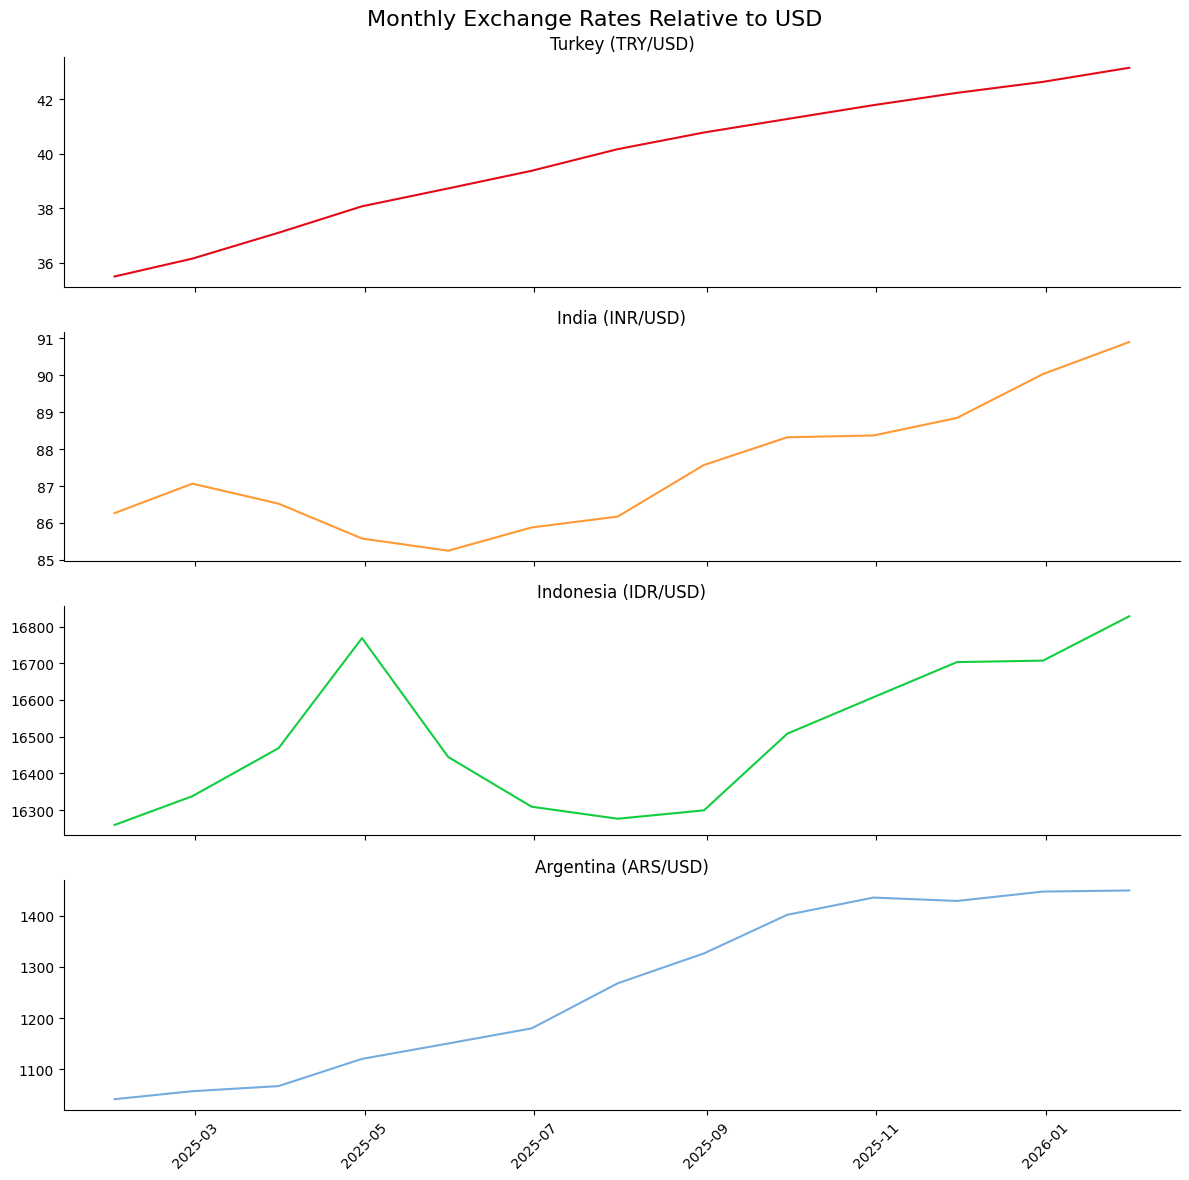

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load CSV files
# -----------------------------

df_turkey = pd.read_csv("../data/turkey.csv")
df_india = pd.read_csv("../data/india.csv")
df_indonesia = pd.read_csv("../data/indonesia.csv")
df_argentina = pd.read_csv("../data/argentina.csv")

# -----------------------------
# Convert dates
# -----------------------------

for df in [df_turkey, df_india, df_indonesia, df_argentina]:
    df["observation_date"] = pd.to_datetime(df["observation_date"])

# -----------------------------
# TIME FILTER
# -----------------------------

start_date = "2025-01-01"
end_date = "2026-02-01"

def filter_df(df):
    return df[
        (df["observation_date"] >= start_date) &
        (df["observation_date"] < end_date)
    ]

df_turkey = filter_df(df_turkey)
df_india = filter_df(df_india)
df_indonesia = filter_df(df_indonesia)
df_argentina = filter_df(df_argentina)

# -----------------------------
# RESAMPLE TO MONTHLY
# -----------------------------

def resample_df(df, col):
    return (
        df.set_index("observation_date")
        .resample("ME")
        .mean()
        .reset_index()
    )

df_turkey = resample_df(df_turkey, "CCUSMA02TRM618N")
df_india = resample_df(df_india, "DEXINUS")
df_indonesia = resample_df(df_indonesia, "CCUSMA02IDM618N")
df_argentina = resample_df(df_argentina, "ARGCCUSMA02STM")

# -----------------------------
# CREATE FIGURE WITH SUBPLOTS
# -----------------------------

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# -----------------------------
# Turkey
# -----------------------------
axes[0].plot(df_turkey["observation_date"], df_turkey["CCUSMA02TRM618N"],
             color="#E30A17")
axes[0].set_title("Turkey (TRY/USD)")

# -----------------------------
# India
# -----------------------------
axes[1].plot(df_india["observation_date"], df_india["DEXINUS"],
             color="#FF9933")
axes[1].set_title("India (INR/USD)")

# -----------------------------
# Indonesia
# -----------------------------
axes[2].plot(df_indonesia["observation_date"], df_indonesia["CCUSMA02IDM618N"],
             color="#11CE40")
axes[2].set_title("Indonesia (IDR/USD)")

# -----------------------------
# Argentina
# -----------------------------
axes[3].plot(df_argentina["observation_date"], df_argentina["ARGCCUSMA02STM"],
             color="#74ACDF")
axes[3].set_title("Argentina (ARS/USD)")

# -----------------------------
# Styling
# -----------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Monthly Exchange Rates Relative to USD", fontsize=16)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [109]:
df_argentina

,observation_date,ARGCCUSMA02STM
0,2025-01-31,1041.913043
1,2025-02-28,1057.537500
2,2025-03-31,1067.505952
3,2025-04-30,1120.619318
4,2025-05-31,1150.647727
5,2025-06-30,1180.130952
6,2025-07-31,1268.184783
7,2025-08-31,1326.500000
8,2025-09-30,1401.897727
9,2025-10-31,1435.489130


In [110]:
print(df_turkey["observation_date"].diff().value_counts().head())
print(df_india["observation_date"].diff().value_counts().head())

observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64


In [111]:
for name, df in {
    "Turkey": df_turkey,
    "India": df_india,
    "Indonesia": df_indonesia,
    "Argentina": df_argentina
}.items():

    print(name)
    print(df["observation_date"].diff().value_counts().head())
    print("-" * 40)

Turkey
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
India
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
Indonesia
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
Argentina
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------


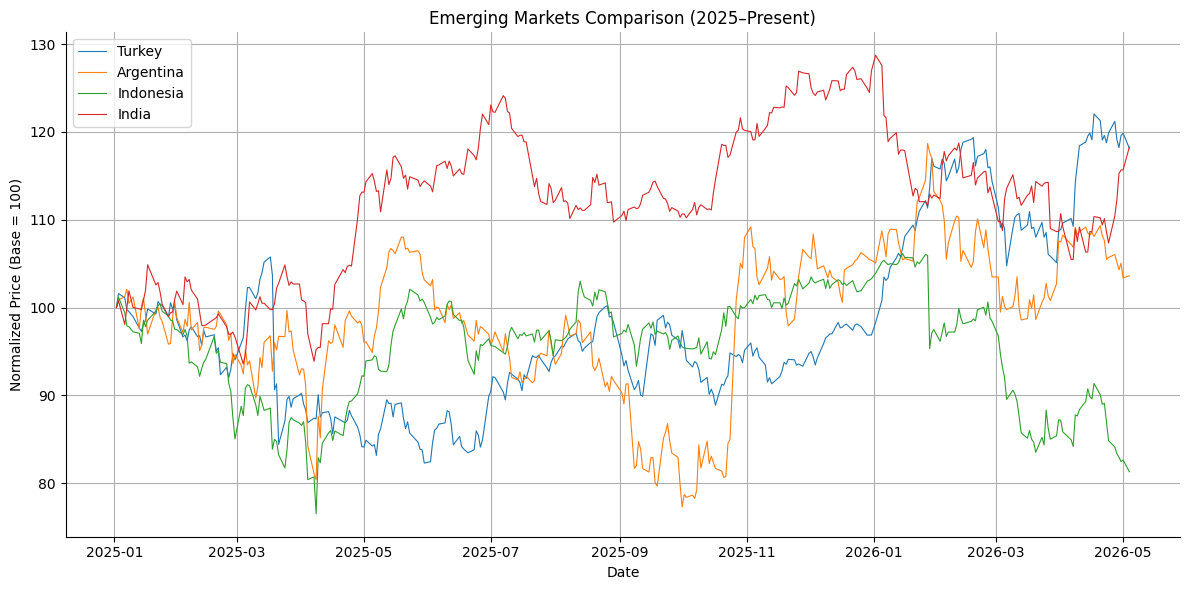

In [112]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = {
    "Turkey": "TUR",
    "Argentina": "ARGT",
    "Indonesia": "EIDO",
    "India": "RELIANCE.NS"
}

start_date = "2025-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

data = pd.DataFrame()

# DOWNLOAD LOOP
for name, ticker in tickers.items():
    print(f"Downloading {ticker}...")

    try:
        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            progress=False,
            timeout=10
        )

        if df.empty:
            print(f"⚠️ No data for {ticker}")
            continue

        if "Adj Close" in df.columns:
            data[name] = df["Adj Close"]
        else:
            data[name] = df["Close"]

    except Exception as e:
        print(f"❌ Failed for {ticker}: {e}")

if data.empty:
    raise ValueError("No data downloaded. Check internet or tickers.")

# CLEAN + NORMALISE
data = data.ffill()
normalized = data / data.iloc[0] * 100

# ✅ CORRECT FIGURE SETUP
fig, ax = plt.subplots(figsize=(12, 6))

# PLOT USING AX (not plt)
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=0.8)

# TITLES + LABELS
ax.set_title("Emerging Markets Comparison (2025–Present)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 100)")

# LEGEND + GRID
ax.legend()
ax.grid(True)

# REMOVE SPINES (correct way)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

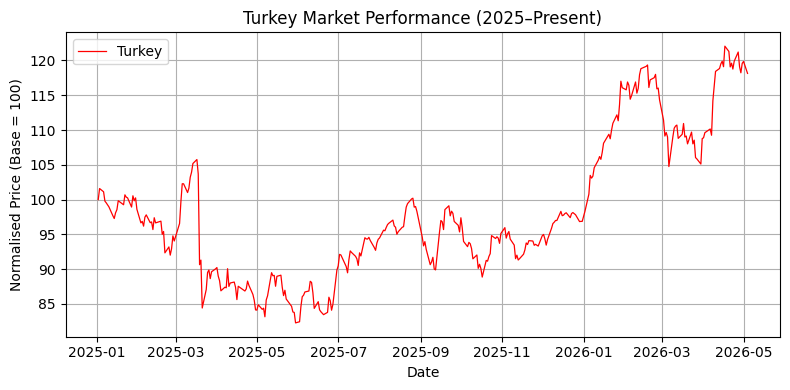

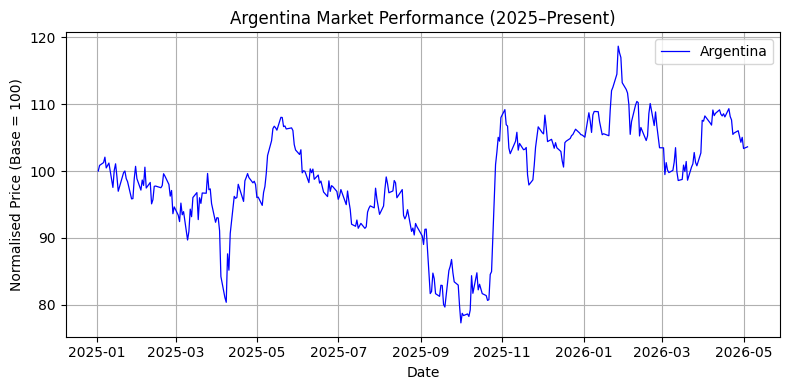

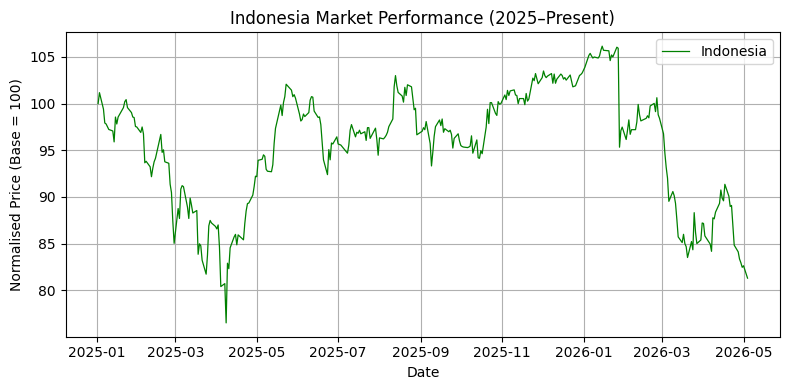

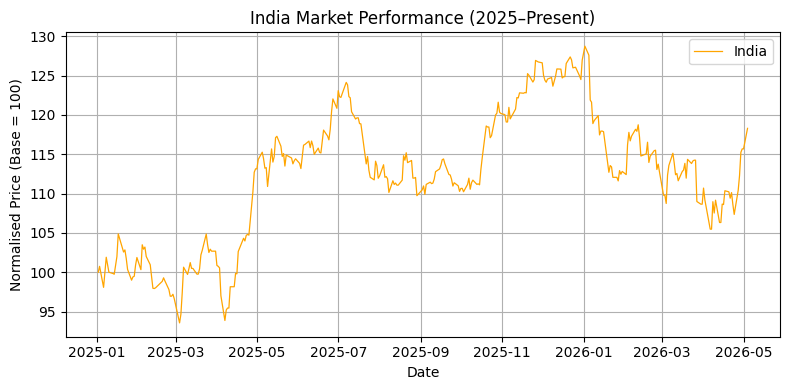

In [113]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# TICKERS
tickers = {
    "Turkey": "TUR",
    "Argentina": "ARGT",
    "Indonesia": "EIDO",
    "India": "RELIANCE.NS"
}

start_date = "2025-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

data = pd.DataFrame()

# -------------------------
# DOWNLOAD
# -------------------------
for name, ticker in tickers.items():
    print(f"Downloading {ticker}...")

    try:
        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            progress=False,
            timeout=10
        )

        if df.empty:
            print(f"No data for {ticker}")
            continue

        if "Adj Close" in df.columns:
            data[name] = df["Adj Close"]
        else:
            data[name] = df["Close"]

    except Exception as e:
        print(f"Failed for {ticker}: {e}")

if data.empty:
    raise ValueError("No data downloaded.")

# CLEAN + NORMALISE
data = data.ffill()
normalized = data / data.iloc[0] * 100

# CUSTOM COLOURS
colors = {
    "Turkey": "red",        
    "Argentina": "blue",   
    "Indonesia": "green",
    "India": "orange"         
}

# -------------------------
# SEPARATE PLOTS
# -------------------------
for country in normalized.columns:
    plt.figure(figsize=(8, 4))
    
    plt.plot(
        normalized.index,
        normalized[country],
        color=colors[country],
        label=country,
        linewidth=0.9
    )
    
    plt.title(f"{country} Market Performance (2025–Present)")
    plt.xlabel("Date")
    plt.ylabel("Normalised Price (Base = 100)")
    plt.legend()
    plt.grid(True)
    
    
    plt.tight_layout()
    plt.show()


In [114]:
from transformers import pipeline

finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

Loading weights: 100%|██████████| 201/201 [00:00<?, ?it/s]


In [115]:
result = finbert("Turkey inflation falls faster than expected")

print(result)

[{'label': 'negative', 'score': 0.7823788523674011}]


In [116]:
conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()


query = "SELECT title FROM articles LIMIT 10"

df_test_finbert = pd.read_sql_query(query, conn)

print(df_test_finbert, "\n")

for rows in df_test_finbert["title"]:
    print(rows)
    print(finbert(rows))
    print("\n")

conn.close()

                                               title
0  FTSE 100 hits 10,000 point milestone for first...
1  Jaguar Land Rover sales slump sharply amid US ...
2  FTSE 100 posts best day in six months as stock...
3  Deep in the vaults: the Bank of England’s £1.4...
4  ‘Shadow fleet’ ships moving sanctioned oil ref...
5  Pub chain shares rise on reports of government...
6  US economy added fewer jobs than forecast in D...
7  High costs, falling returns: what could go wro...
8  Why Russia’s economy is unlikely to collapse e...
9  Trump move for Venezuela’s resources likely to... 

FTSE 100 hits 10,000 point milestone for first time, after best year of gains since 2009 – as it happened
[{'label': 'positive', 'score': 0.8794516324996948}]


Jaguar Land Rover sales slump sharply amid US tariffs and cyber-attack
[{'label': 'negative', 'score': 0.9734575748443604}]


FTSE 100 posts best day in six months as stock market rally continues – as it happened
[{'label': 'positive', 'score': 0.7235189

In [117]:
import sqlite3

conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()

cursor.execute("PRAGMA table_info(articles)")

for row in cursor.fetchall():
    print(row)

conn.close()

(0, 'article_id', 'TEXT', 0, None, 1)
(1, 'country', 'TEXT', 0, None, 0)
(2, 'date', 'TEXT', 0, None, 0)
(3, 'source_name', 'TEXT', 0, None, 0)
(4, 'title', 'TEXT', 0, None, 0)
(5, 'description', 'TEXT', 0, None, 0)
(6, 'url', 'TEXT', 0, None, 0)
(7, 'published_at', 'TEXT', 0, None, 0)
(8, 'sentiment_score', 'REAL', 0, None, 0)
(9, 'sentiment_score_vader', 'REAL', 0, None, 0)
(10, 'sentiment_score_finbert', 'REAL', 0, None, 0)


In [118]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/articles.db")

check_query = """
SELECT title, sentiment_score_vader, date, country
FROM articles
"""

df = pd.read_sql_query(check_query, conn)

conn.close()

df

,title,sentiment_score_vader,date,country
0,"FTSE 100 hits 10,000 point milestone for first...",0.625000,2026-01-02,India
1,Jaguar Land Rover sales slump sharply amid US ...,-0.125000,2026-01-06,India
2,FTSE 100 posts best day in six months as stock...,1.000000,2026-01-06,India
3,Deep in the vaults: the Bank of England’s £1.4...,0.000000,2026-01-06,Vietnam
4,‘Shadow fleet’ ships moving sanctioned oil ref...,0.000000,2026-01-08,Turkey
...,...,...,...,...
574,Temporary protected status holders add $29bn t...,0.000000,2026-04-22,Turkey
575,Strait of Hormuz is hosting gunboat diplomacy ...,0.550000,2026-04-22,Turkey
576,Zelenskyy says EU unblocking of €90bn loan for...,0.285714,2026-04-22,Turkey
577,Trump approval slips as polls show warning sig...,0.000000,2026-04-22,Turkey


In [119]:
print(df_finbert["country"].value_counts())

country
Turkey       375
India         73
Vietnam       44
Argentina     43
Indonesia     26
Nigeria       18
Name: count, dtype: int64


In [ ]:
#make a turkey cumulative sentiment chart 